# Evaluation and Clinical Validation

## Motivation Questions:

#### If a test has 90% sensitivity and 90% specificity: 
#### - What is the probability that a positive test means cancer?
#### - How many false alarms will clinicians receive?
#### - Would you accept this system in an ICU? 


## Prevalence and Positive Predictive Value (PPV)

This notebook demonstrates how **disease prevalence affects the Positive Predictive Value (PPV)** of a screening test.

Even when **sensitivity and specificity are high**, low prevalence can cause most positive results to be **false positives**.


### Run the following cells and complete the exercise below:

We first need to import some tools for working with data in Python. 
- NumPy is for working with numbers
- Pandas is for analysing data
- MatPlotLib is for making plots

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Define parameters

population = 100000

prevalence = 0.01      # 1% disease prevalence
sensitivity = 0.90
specificity = 0.90

In [12]:

disease = population * prevalence
healthy = population - disease

print(f"Total population: {population}")
print(f"Disease cases: {disease}")
print(f"Healthy cases: {healthy}")


Total population: 100000
Disease cases: 1000.0
Healthy cases: 99000.0


In [13]:
# Compute Confusion Matrix

disease = population * prevalence
healthy = population - disease

TP = sensitivity * disease
FN = disease - TP

TN = specificity * healthy
FP = healthy - TN

results = pd.DataFrame({
    "Outcome": ["True Positive","False Negative","True Negative","False Positive"],
    "Count": [TP, FN, TN, FP]
})

results

,Outcome,Count
0,True Positive,900.0
1,False Negative,100.0
2,True Negative,89100.0
3,False Positive,9900.0


In [14]:
print(f"Total number of alerts: {TP+FP}")


Total number of alerts: 10800.0


Only 900 of the 10.800 total number of alerts are real!

This is reflected in the metric: Positive Predictive Value. 

In [15]:
# Compute Predictive Values (Positive and Negative)

PPV = TP / (TP + FP)
NPV = TN / (TN + FN)

print("Positive Predictive Value (PPV):", round(PPV,3))
print("Negative Predictive Value (NPV):", round(NPV,3))

Positive Predictive Value (PPV): 0.083
Negative Predictive Value (NPV): 0.999


#### Answer to the question:

The probability that a positive test means cancer is **~8%**!!


#### Note:

**Sensitivity** and **specificity** are prevalence-independent test characteristics, as their values are intrinsic to the test and do not depend on the disease prevalence in the population of interest.

However, positive and negative **predictive values** are values influenced by the prevalence of disease in the population that is being tested.

### How prevalence affect Positive Predictive Value (PPV)

Let's explore the effect of prevalence on Positive Predictive Value (PPV).

In [16]:
# Compute PPV for several prevalence values (given sensitivity=0.9 and specificity=0.9)

prevalences = np.linspace(0.001,0.2,100)
ppv_values = []

for p in prevalences:

    disease = population * p
    healthy = population - disease

    TP = sensitivity * disease
    FN = disease - TP

    TN = specificity * healthy
    FP = healthy - TN

    PPV = TP/(TP+FP)

    ppv_values.append(PPV)

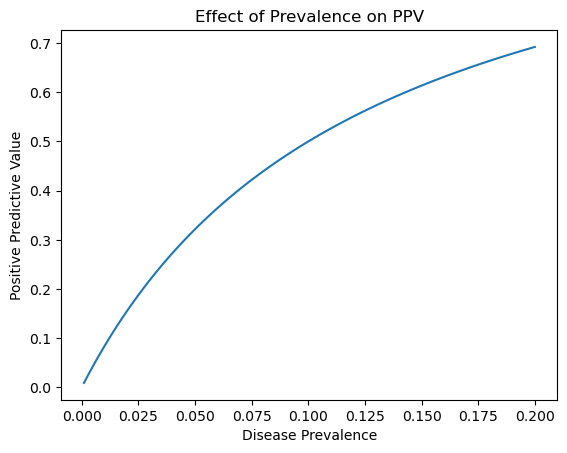

In [17]:
# Plot the Result
plt.plot(prevalences, ppv_values)

plt.xlabel("Disease Prevalence")
plt.ylabel("Positive Predictive Value")

plt.title("Effect of Prevalence on PPV")

plt.show()


### Exercise: 

Try changing the parameters:

1. prevalence = 0.001 (0.1%)
2. sensitivity = 0.99
3. specificity = 0.95

Questions:

- What happens to PPV when prevalence becomes very low?
- Why do screening programs generate many false positives?
- Why is **accuracy misleading** for rare diseases?